In [2]:
import sys
from pathlib import Path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent

import networkx as nx
sys.path.append(str(ROOT))
from torch_geometric.utils import degree
import torch
from src.models.mlp import MLP
from src.models.svm import evaluate_with_svm
from node2vec import Node2Vec
from src.methods.posEnc import LaplacianPosEnc
from src.plotting import visualize_embeddings_grid
from torch_geometric.datasets import HeterophilousGraphDataset

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("device: ", device)

DATA_ROOT = Path("/Users/emely/Uni/Thesis/Thesis/data")  
DATA_ROOT.mkdir(parents=True, exist_ok=True)

dataset = HeterophilousGraphDataset(root=str(DATA_ROOT), name='roman-empire')
data = dataset[0]
print(data)
deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
print(f"Avg Degree: {deg.mean().item():.2f}")

device:  mps
Data(x=[22662, 300], edge_index=[2, 65854], y=[22662], train_mask=[22662, 10], val_mask=[22662, 10], test_mask=[22662, 10])
Avg Degree: 2.91


In [3]:
# node2vec

G = nx.Graph()

G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(data.edge_index.t().tolist())

node2vec = Node2Vec(G, 
            dimensions=64,
            walk_length=30, 
            num_walks=20,
            p = 1.0, 
            q = 0.5,
            workers=5)

model = node2vec.fit(window = 10, min_count=1, batch_words=5)
emb_node2vec = torch.tensor([model.wv[str(n)] for n in range(data.num_nodes)])

print(emb_node2vec.shape) 

Computing transition probabilities:   0%|          | 0/22662 [00:00<?, ?it/s]

Generating walks (CPU: 5): 100%|██████████| 4/4 [00:04<00:00,  1.03s/it]


torch.Size([22662, 64])


/var/folders/t_/hzd73tvn4xj14njtt5ztk4dr0000gn/T/ipykernel_50907/214811272.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  emb_node2vec = torch.tensor([model.wv[str(n)] for n in range(data.num_nodes)])


In [4]:
# posEnc

pos_enc = LaplacianPosEnc(k=32)
data_posEnc = pos_enc(data)
emb_posEnc = data_posEnc.x

print(emb_posEnc.shape)

torch.Size([22662, 332])


In [5]:
# original features
emb_original = data.x.clone().to(device)
print(emb_original)


tensor([[-0.0493,  0.0997,  0.0219,  ...,  0.0067, -0.0084, -0.0079],
        [ 0.0922, -0.0325,  0.0003,  ...,  0.0067, -0.0084, -0.0079],
        [ 0.0067,  0.0278,  0.0351,  ...,  0.0082, -0.0103, -0.0097],
        ...,
        [ 0.0142, -0.0185,  0.0129,  ...,  0.0106,  0.0089, -0.0073],
        [ 0.0120, -0.0353, -0.0055,  ...,  0.0086,  0.0073, -0.0059],
        [-0.0073,  0.0157, -0.0554,  ...,  0.0136,  0.0115, -0.0094]],
       device='mps:0')


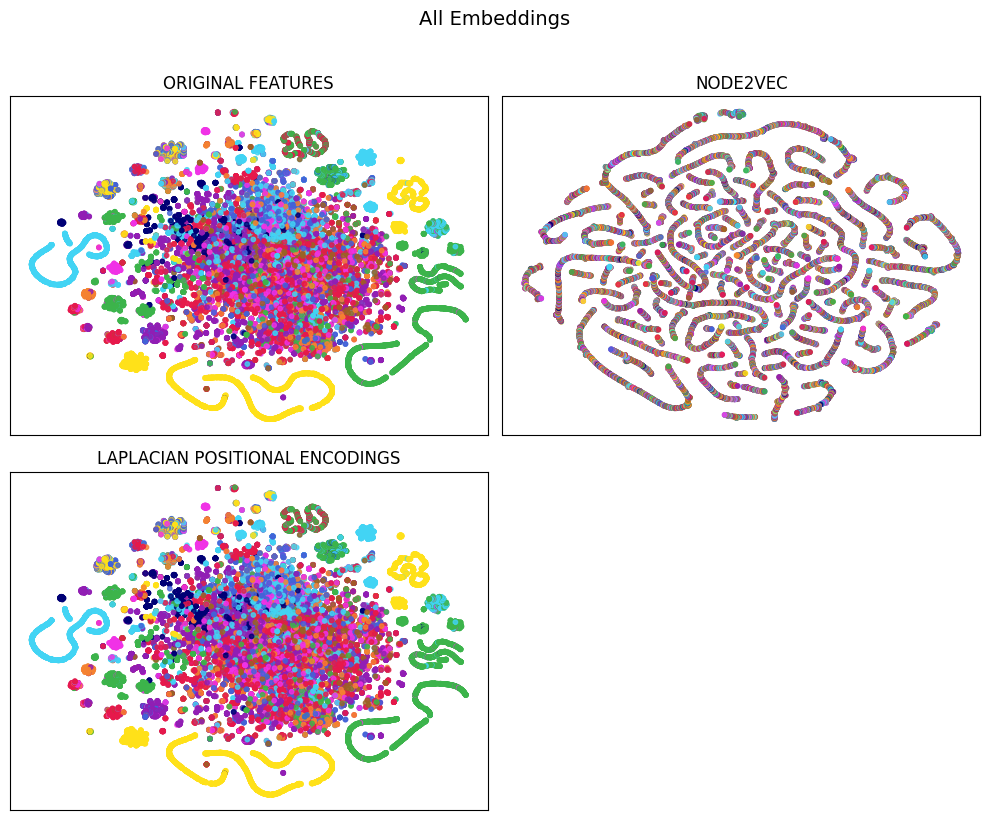

In [6]:
labels = data.y
all_embeddings = {
    "Original Features": emb_original.cpu(),
    "Node2Vec": emb_node2vec.cpu(),
    "Laplacian Positional Encodings": emb_posEnc.cpu()
}
visualize_embeddings_grid(all_embeddings, labels, title= "All Embeddings")



MLP on LAPLACIANPOSENC embeddings
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=1e-05 | Val 0.6032
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0001 | Val 0.5920
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0005 | Val 0.5980
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=1e-05 | Val 0.6064
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0001 | Val 0.6151
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0005 | Val 0.6171
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=1e-05 | Val 0.6234
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0001 | Val 0.6434
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0005 | Val 0.6363
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=1e-05 | Val 0.7900
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0001 | Val 0.7919
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0005 | Val 0.7914
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.001, wd=1e-05 | Val 0.8659
[L

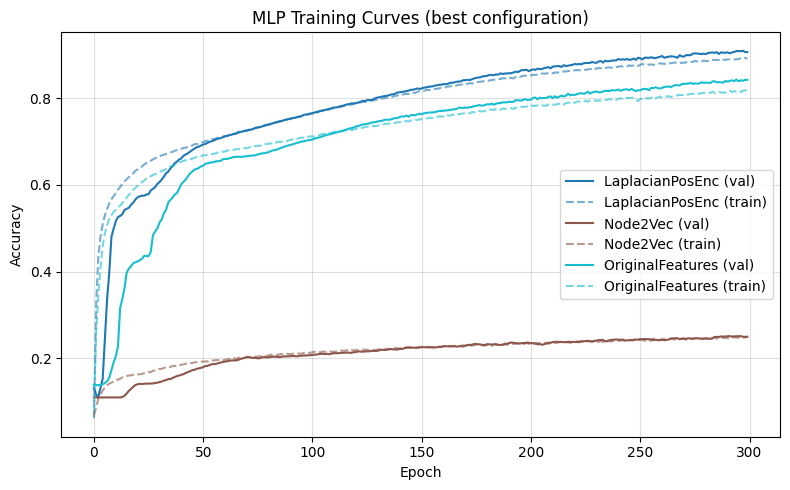

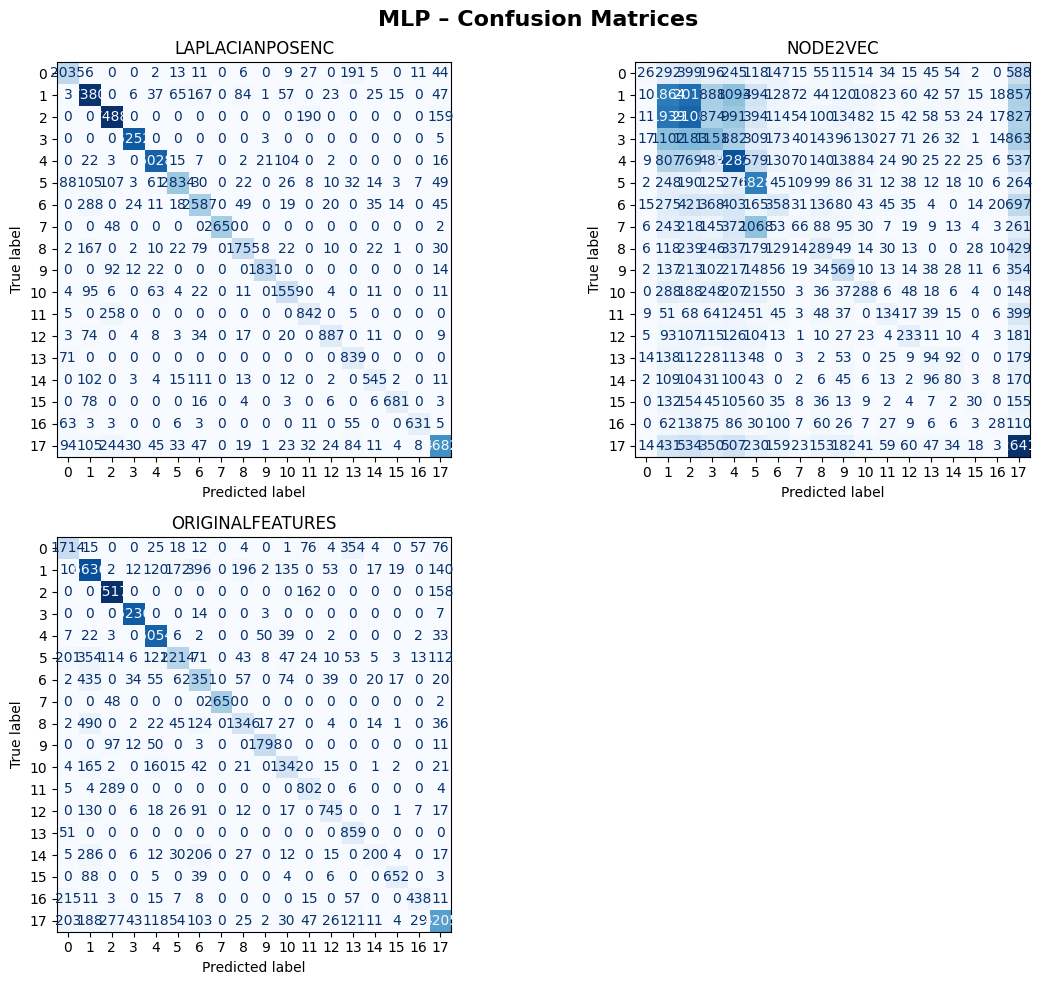

In [7]:
# evaluate with MLP 

results_dir = Path("/Users/emely/Uni/Thesis/Thesis/roman-empire/results")
results_dir.mkdir(parents=True, exist_ok=True)

embeddings = {
    "LaplacianPosEnc": emb_posEnc,
    "Node2Vec": emb_node2vec,
    "OriginalFeatures": emb_original
}

best_results, best_acc = MLP.evaluate_with_mlp(
    embeddings=embeddings,
    data=data,
    device=device,
    mlp_epochs=300
)

torch.save(best_acc, results_dir / "best_acc_node_pos.pt")
emb_file = Path("/Users/emely/Uni/Thesis/Thesis/roman-empire/results/embeddings.pt")

if emb_file.exists():
    all_embeddings = torch.load(emb_file)
else:
    all_embeddings = {}

for name, emb_tensor in embeddings.items():
    all_embeddings[name] = {name: emb_tensor.detach().cpu()}

torch.save(all_embeddings, emb_file)




SVM on LAPLACIANPOSENC embeddings
C=0.01 | Val Acc=0.5822
C=0.1 | Val Acc=0.6000
C=1 | Val Acc=0.6028
C=10 | Val Acc=0.6011
Best C=1 | Test Acc=0.6130


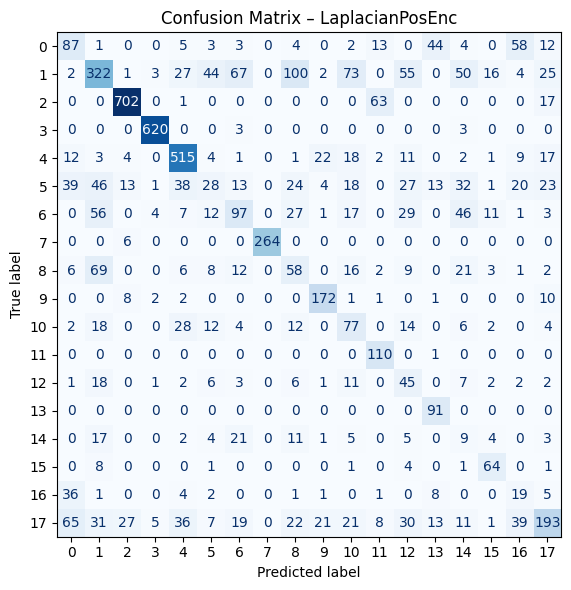


SVM on NODE2VEC embeddings
C=0.01 | Val Acc=0.0383
C=0.1 | Val Acc=0.0348
C=1 | Val Acc=0.0348
C=10 | Val Acc=0.0369
Best C=0.01 | Test Acc=0.0339


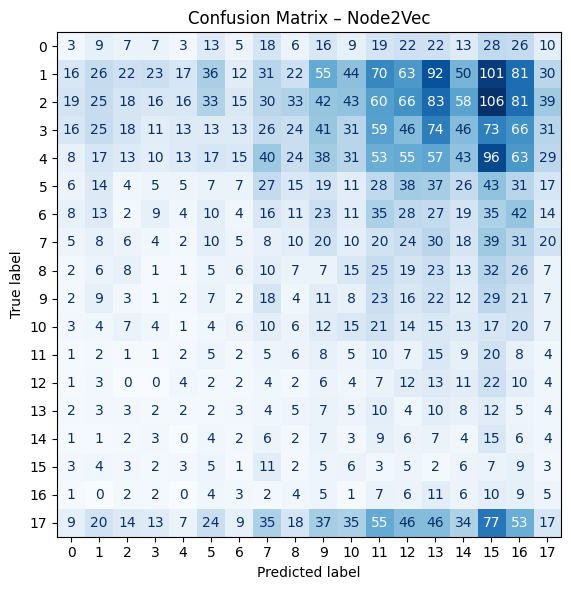


SVM on ORIGINALFEATURES embeddings
C=0.01 | Val Acc=0.5822
C=0.1 | Val Acc=0.6000
C=1 | Val Acc=0.6026
C=10 | Val Acc=0.6011
Best C=1 | Test Acc=0.6128


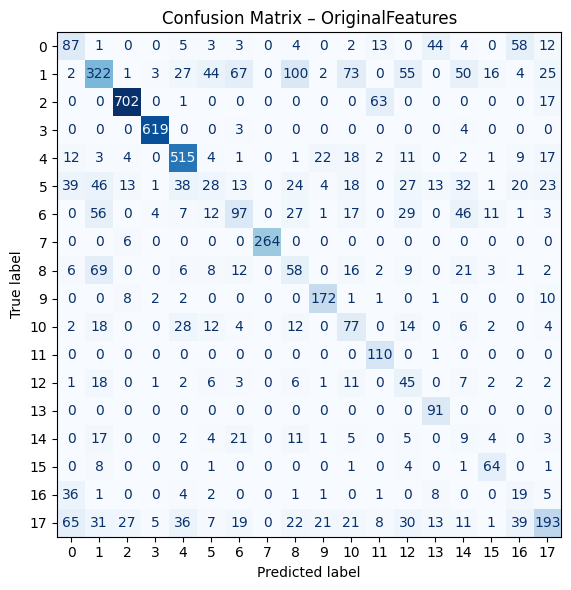

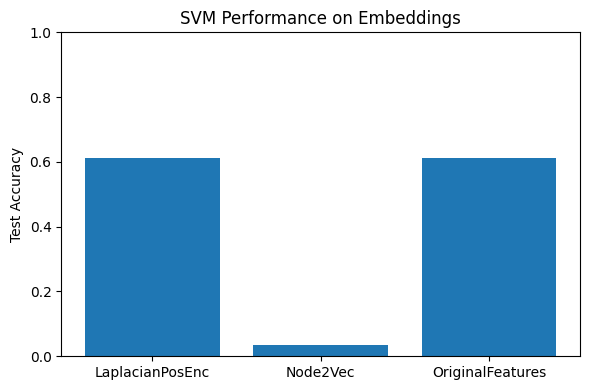

In [9]:
# evaluate with SVM

svm_results = evaluate_with_svm(
    embeddings=embeddings,
    data=data,
    device=device
)
torch.save(svm_results,"/Users/emely/Uni/Thesis/Thesis/roman-empire/results/svm_results_node_pos.pt")